In [33]:
ticker = "AAPL"
df = pd.read_csv(f"rl_dfs/train/{ticker}.csv", index_col=0)
df.index = pd.to_datetime(df.index)


In [34]:
env = TradeEnv(data=df.loc[df.index[:500]], ticker=ticker, verbose=True)

env.reset()
while True:
    action = env.action_space.sample()
    obs, reward, done, _, info = env.step(action)
    print(f"Action: {action} | Reward: {reward} | Done: {done}")
    if done:
        break

Reset Environment at 20241228-18h43
Reset Environment at 20241228-18h43
Action: 1 | Reward: 0 | Done: False
Action: 0 | Reward: -0.00034167007896693436 | Done: False
Action: 1 | Reward: 0.0 | Done: False
Action: 2 | Reward: 5.832655287150897e-05 | Done: False
Action: 1 | Reward: 0 | Done: False
Action: 2 | Reward: -0.0004 | Done: False
Action: 2 | Reward: -0.00011615093317648237 | Done: False
Action: 0 | Reward: 5.8374083307936166e-05 | Done: False
Action: 1 | Reward: 0 | Done: False
Action: 1 | Reward: 0 | Done: False
Action: 0 | Reward: -0.0005745486982111259 | Done: False
Action: 2 | Reward: -0.00011615093317648237 | Done: False
Action: 1 | Reward: 0 | Done: False
Action: 2 | Reward: -0.0004 | Done: False
Action: 1 | Reward: 0.0 | Done: False
Action: 1 | Reward: -0.0 | Done: False
Action: 1 | Reward: 0.0 | Done: False
Action: 1 | Reward: 0.0 | Done: False
Action: 2 | Reward: -5.778363007262985e-05 | Done: False
Action: 1 | Reward: 0.0 | Done: False
Action: 1 | Reward: 0.0 | Done: Fa


==== Final Metrics ====
Total Return : 0.96
Sharpe Ratio : -0.49
Max Drawdown : 0.01
Hit Ratio : 0.28
Number of operations:  96


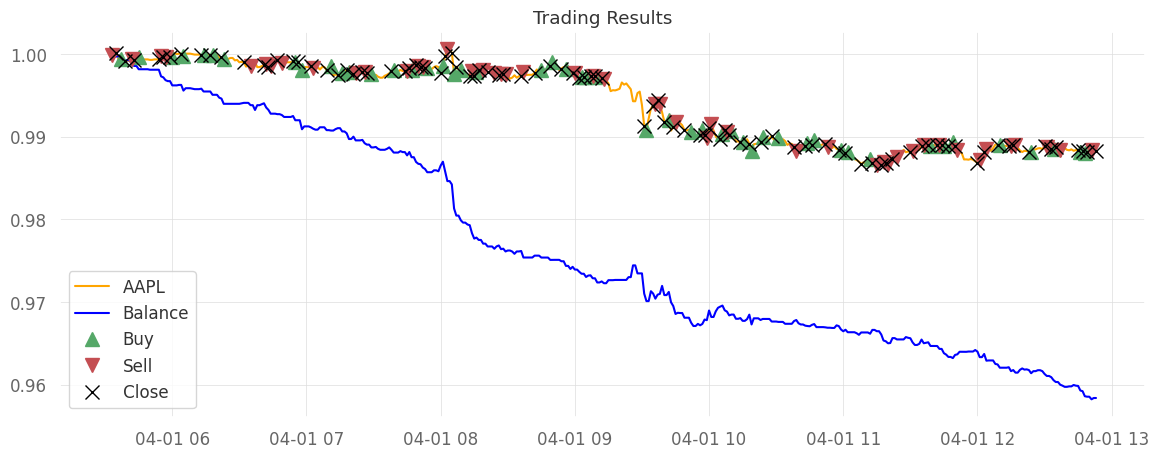

,open_time,close_time,returns,type
0,2024-04-01 05:33:00,2024-04-01 05:35:00,-0.000225,short
1,2024-04-01 05:37:00,2024-04-01 05:39:00,-0.000458,long
2,2024-04-01 05:42:00,2024-04-01 05:43:00,-0.000865,short
3,2024-04-01 05:45:00,2024-04-01 05:54:00,-0.000458,long
4,2024-04-01 05:55:00,2024-04-01 05:56:00,-0.001332,short
...,...,...,...,...
91,2024-04-01 12:34:00,2024-04-01 12:35:00,-0.000576,long
92,2024-04-01 12:37:00,2024-04-01 12:45:00,-0.000433,short
93,2024-04-01 12:46:00,2024-04-01 12:47:00,-0.000841,long
94,2024-04-01 12:48:00,2024-04-01 12:49:00,-0.000930,long


In [35]:
env.show_final_results()

In [14]:
def show_final_results(self, saving_path: str = None):
        df = pd.DataFrame.from_dict(self.memory, orient='index')
        df.index = pd.to_datetime(df.index)
        df = df.astype(float)
        ticker_info = self.data.loc[self.data.index.isin(df.index)]
        ticker_info = ticker_info[['close_real']]
        ticker_info = ticker_info.dropna()
        ticker_info['close_real'] = ticker_info.values / ticker_info.values[0]
        df['current_balance'] = df['current_balance'] / df['current_balance'].iloc[0]
        df_positions = pd.DataFrame.from_dict(self.position_memory)
        df_positions.open_time = pd.to_datetime(df_positions.open_time)
        df_positions.close_time = pd.to_datetime(df_positions.close_time)
        df_close = []
        df_arrow_up = []
        df_arrow_down = []
        for row_iter in df_positions.iterrows():
            row = row_iter[1]
            close_value = (ticker_info.loc[ticker_info.index == row["close_time"]]).close_real.values[0]
            close_date = row["close_time"]
            df_close.append({"date":close_date, "x_close":close_value})
            open_date = row["open_time"]
            open_value = (ticker_info.loc[ticker_info.index == row["open_time"]]).close_real.values[0]
            if row["type"] == "long":
                df_arrow_up.append({"date":open_date, "arrow_up":open_value})
            elif row["type"] == "short":
                df_arrow_down.append({"date":open_date, "arrow_down":open_value})
        df_close = pd.DataFrame(df_close)
        if len(df_close) > 0:
            df_close.set_index("date", inplace=True)
        df_arrow_up = pd.DataFrame(df_arrow_up)
        if len(df_arrow_up) > 0:
            df_arrow_up.set_index("date", inplace=True)
        df_arrow_down = pd.DataFrame(df_arrow_down)
        if len(df_arrow_down) > 0:
            df_arrow_down.set_index("date", inplace=True)
        
        df = pd.concat([df, df_close, df_arrow_up, df_arrow_down], axis=1)
        self._print_info(df_positions.returns.values, "Final Metrics")
        plt.figure(figsize=(14, 5))
        plt.plot(ticker_info, label=self.ticker, color='orange')
        plt.plot(df['current_balance'], label='Balance', color='blue')
        if len(df_arrow_up) > 0:
            plt.plot(df['arrow_up'], label='Buy', marker='^', markersize=10, color='g', lw=0)
        if len(df_arrow_down) > 0:
            plt.plot(df['arrow_down'], label='Sell', marker='v', markersize=10, color='r', lw=0)
        plt.plot(df['x_close'], label='Close', marker='x', markersize=10, color='black', lw=0)
        plt.title('Trading Results')
        plt.legend()

        if saving_path is not None:
            df_positions.to_csv(saving_path + "/df_positions.csv", index=True)
            plt.savefig(saving_path + "/trading_results.png")
        print("Number of operations: ",len(df_positions))
        plt.show()
        return df_positions
    
show_final_results(env)

,reward,current_balance,action,current_returns,x_close,arrow_up,arrow_down
2024-04-01 05:32:00,-0.000458,1.000000,-1.0,-0.000058,NaN,NaN,1.0
2024-04-01 05:33:00,0.000058,1.000058,-1.0,0.000058,NaN,NaN,NaN
2024-04-01 05:34:00,0.000116,1.000174,1.0,0.000116,1.000058,NaN,NaN
2024-04-01 05:35:00,-0.000342,0.999833,1.0,0.000058,NaN,1.000116,NaN
2024-04-01 05:36:00,-0.000756,0.999076,1.0,-0.000756,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2024-07-19 19:55:00,-0.000230,0.001055,1.0,0.000170,NaN,1.306605,NaN
2024-07-19 19:56:00,-0.000045,0.001055,1.0,-0.000045,NaN,NaN,NaN
2024-07-19 19:57:00,-0.000000,0.001055,0.0,-0.000000,NaN,NaN,NaN
2024-07-19 19:58:00,0.000348,0.001055,1.0,0.000348,NaN,NaN,NaN


TypeError: index is not a valid DatetimeIndex or PeriodIndex